In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.serif'] = 'cm'

In [12]:
def backup(filename: str):
    
    if not os.path.exists(filename):
        return
    
    i = 0
    while True:
        bak_filename = f'{filename}.bak' if i == 0 else f'{filename}.bak{i}'
        if not os.path.exists(bak_filename):
            break
        i += 1
    
    os.rename(filename, bak_filename)
    return

data_path = os.path.expanduser('~/OneDrive - Mississippi State University/Classes/ABE7000/data.xlsx')
if not os.path.exists(data_path):
    raise FileNotFoundError(f'Data file not found')

primary_color = 'steelblue'

# Publications Per Year

,Number of Publications
Year,
2014,1
2015,2
2016,12
2017,17
2018,40
2019,63
2020,91
2021,95
2022,123


/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_20031/3765955539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pubs_per_year.index, rotation=0)


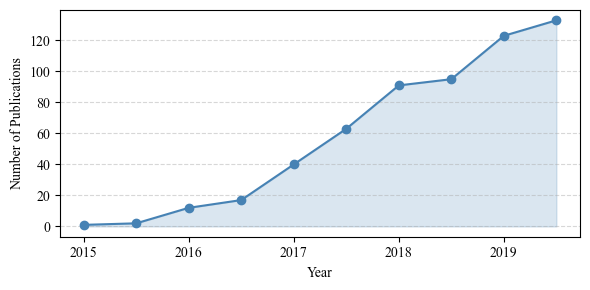

In [13]:
pubs_per_year = pd.read_excel(data_path, sheet_name='vhsr_lulc_pubs_per_year')
pubs_per_year = pubs_per_year.sort_values(by='Year', ascending=True)
pubs_per_year = pubs_per_year.set_index('Year')
pubs_per_year = pubs_per_year.iloc[:-1] # remove 2024 (incomplete)
display(pubs_per_year)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pubs_per_year.plot(kind='line', style='-o', legend=False, ax=ax, color=primary_color)
ax.set_ylabel('Number of Publications')
ax.set_xticklabels(pubs_per_year.index, rotation=0)
# ax.set_title('Number of Publications per Year in Scopus\nSearch Query: "high resolution" AND "deep learning" AND "land cover classification"')
ax.fill_between(pubs_per_year.index, pubs_per_year['Number of Publications'], color=primary_color, alpha=0.2)
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()


pubs_per_year_chart_filename = './pubs_per_year_plot.png'
backup(pubs_per_year_chart_filename)
plt.savefig(pubs_per_year_chart_filename, dpi=300)

plt.show()
plt.close()

# Satellite Timeline Gantt Chart

In [14]:
sat_timeline = pd.read_excel(data_path, sheet_name='satellite_timeline')

sat_timeline = sat_timeline.dropna(subset=['Satellite/Constellation'])
sat_timeline['Launch Date'] = pd.to_datetime(sat_timeline['Launch Date'])
sat_timeline['End of Life Date'] = pd.to_datetime(sat_timeline['End of Life Date'])
sat_timeline['End of Life Date'] = sat_timeline['End of Life Date'].fillna(pd.to_datetime('today'))
sat_timeline['Lifetime'] = sat_timeline['End of Life Date'] - sat_timeline['Launch Date']
sat_timeline['start_offset'] = sat_timeline['Launch Date'] - sat_timeline['Launch Date'].min()
sat_timeline['start_offset'] = sat_timeline['start_offset'].dt.days
sat_timeline['lifetime_days'] = sat_timeline['Lifetime'].dt.days
sat_timeline['end_offset'] = sat_timeline['start_offset'] + sat_timeline['lifetime_days']
sat_timeline['end_offset'] = sat_timeline['end_offset'].clip(upper=sat_timeline['end_offset'].max())
sat_timeline

,Satellite/Constellation,Launch Date,End of Life Date,Lifetime,start_offset,lifetime_days,end_offset
0,IKONOS,1999-09-24,2015-03-31 00:00:00.000000,5667 days 00:00:00,0,5667,5667
1,QuickBird,2001-10-18,2015-01-27 00:00:00.000000,4849 days 00:00:00,755,4849,5604
2,OrbView-3,2003-06-26,2007-04-23 00:00:00.000000,1397 days 00:00:00,1371,1397,2768
3,GeoEye-1,2008-09-06,2024-10-24 12:13:03.965070,5892 days 12:13:03.965070,3270,5892,9162
4,RapidEye,2008-08-29,2020-03-31 00:00:00.000000,4232 days 00:00:00,3262,4232,7494
5,WorldView-1,2007-09-18,2024-10-24 12:13:03.965070,6246 days 12:13:03.965070,2916,6246,9162
6,WorldView-2,2009-10-01,2024-10-24 12:13:03.965070,5502 days 12:13:03.965070,3660,5502,9162
7,WorldView-3,2014-08-13,2024-10-24 12:13:03.965070,3725 days 12:13:03.965070,5437,3725,9162
8,WorldView-4,2016-11-11,2019-01-07 00:00:00.000000,787 days 00:00:00,6258,787,7045
9,SPOT-5,2002-05-04,2015-03-27 00:00:00.000000,4710 days 00:00:00,953,4710,5663


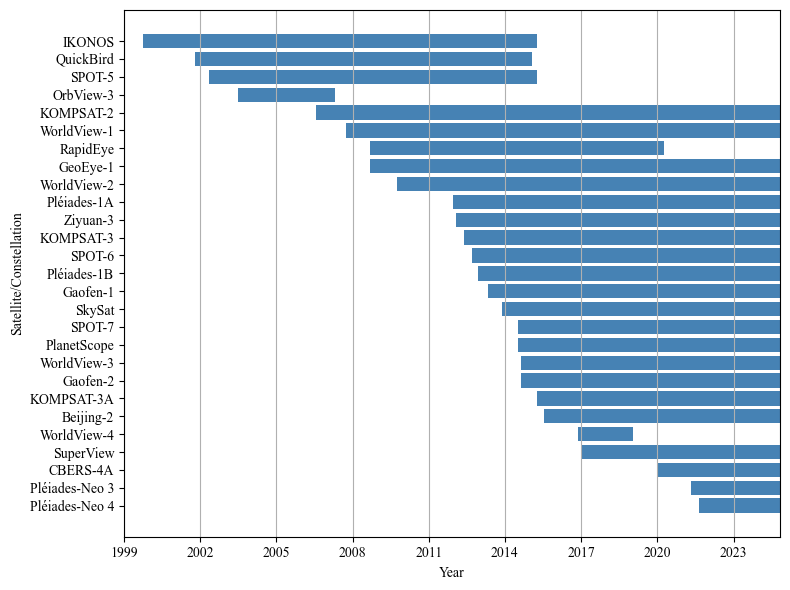

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sat_timeline = sat_timeline.sort_values(by='start_offset', ascending=False)
ax.barh(y=sat_timeline['Satellite/Constellation'], width=sat_timeline['lifetime_days'], left=sat_timeline['start_offset'], color=primary_color)

first_launch = sat_timeline['Launch Date'].min()
x_start_offset = (pd.to_datetime(f'1/1/{first_launch.year}') - first_launch).days

ax.set_xlim(x_start_offset, sat_timeline['end_offset'].max())

# display every 3 years in 01/YYYY format on x-axis
x_ticks = np.arange(x_start_offset, sat_timeline['end_offset'].max(), 365 * 3)
x_labels = [f'{year}' for year in np.arange(first_launch.year, sat_timeline['End of Life Date'].max().year, 3)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)

# enable x-axis grid
ax.xaxis.grid(True)

ax.set_ylabel('Satellite/Constellation')
ax.set_xlabel('Year')

fig.tight_layout()

sat_timeline_plot_filename = './satellite_lifetime.png'
backup(sat_timeline_plot_filename)
plt.savefig(sat_timeline_plot_filename)

plt.show()
plt.close()

# Spectral Resolutions

CBERS-4A 0
['Blue', 'Green', 'Red', 'NIR']
SuperView 1
['Blue', 'Green', 'Red', 'NIR']
WorldView-4 2
['Blue', 'Green', 'Red', 'NIR']
Beijing-2 3
['Blue', 'Green', 'Red', 'NIR']
KOMPSAT-3A 4
['Blue', 'Green', 'Red', 'NIR']
Gaofen-2 5
['Blue', 'Green', 'Red', 'NIR']
WorldView-3 6
['Coastal Aerosol', 'Blue', 'Green', 'Yellow', 'Red', 'Red-Edge', 'NIR', 'NIR I']
PlanetScope Dove-C 7
['Blue', 'Green', 'Red', 'NIR']
PlanetScope Dove-R 8
['Blue', 'Green', 'Red', 'NIR']
PlanetScope SuperDove 9
['Coastal Aerosol', 'Blue', 'Green I', 'Green', 'Yellow', 'Red', 'Red-Edge', 'NIR']
SPOT-7 10
['Blue', 'Green', 'Red', 'NIR']
SkySat 11
['Blue', 'Green', 'Red', 'NIR']
Gaofen-1 12
['Blue', 'Green', 'Red', 'NIR']
SPOT-6 13
['Blue', 'Green', 'Red', 'NIR']
KOMPSAT-3 14
['Blue', 'Green', 'Red', 'NIR']
Ziyuan-3 15
['Blue', 'Green', 'Red', 'NIR']
WorldView-2 16
['Coastal Aerosol', 'Blue', 'Green', 'Yellow', 'Red', 'Red-Edge', 'NIR', 'NIR I']
GeoEye-1 17
['Blue', 'Green', 'Red', 'NIR']
RapidEye 18
['Blue', 'Gre

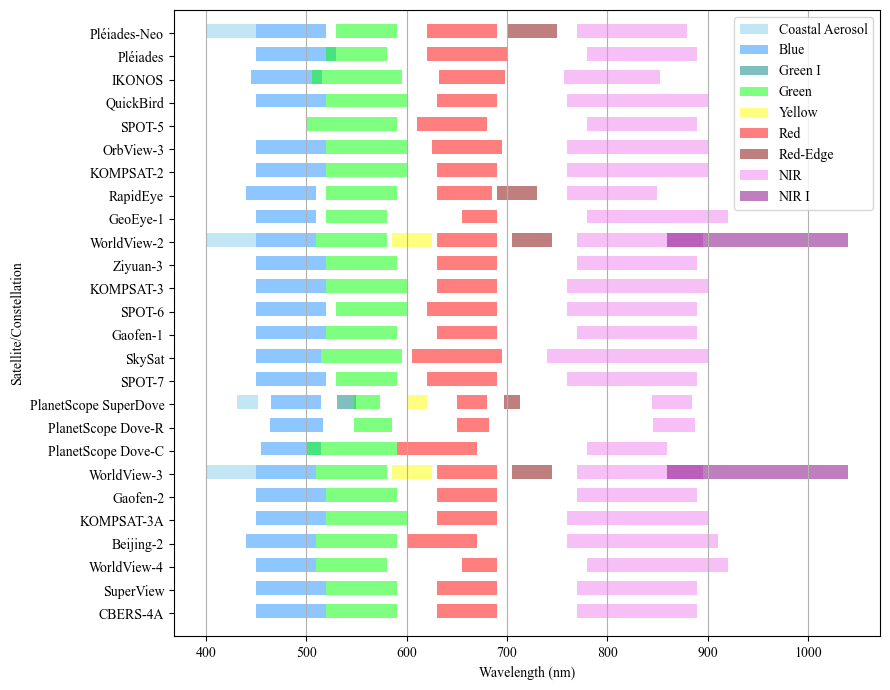

In [20]:
color_map = {
    'Coastal Aerosol': 'skyblue', 
    'Blue': 'dodgerblue',
    'Green I': 'teal',
    'Green': 'lime', 
    'Yellow': 'yellow', 
    'Red': 'red', 
    'Red-Edge': 'maroon', 
    'NIR': 'violet', 
    'NIR I': 'purple',
}

spectral_resolution_df = pd.read_excel(data_path, sheet_name='spectral_resolutions')
spectral_resolution_df
band_names = spectral_resolution_df.iloc[0].values[1:]
spectral_resolution_df.columns = [spectral_resolution_df.columns[0]] + band_names.tolist()
spectral_resolution_df = spectral_resolution_df.drop(["Notes", "Citation", "Panchromatic"], axis=1)
band_names = [band for band in band_names if band not in ['Notes', 'Citation', 'Panchromatic']]
spectral_resolution_df = spectral_resolution_df.drop(0)
# drop worldview-1 as it has no multispectral sensor
spectral_resolution_df = spectral_resolution_df.drop(spectral_resolution_df[spectral_resolution_df['Satellite/Constellation'] == 'WorldView-1'].index)
spectral_resolution_df = spectral_resolution_df.reset_index()

# order by launch date, so that the plot is in the same order as the lifetime plot
# need to get values for launch date from sat_timeline
# sat_timeline = sat_timeline.set_index('Satellite/Constellation')
spectral_resolution_df['Launch Date'] = spectral_resolution_df['Satellite/Constellation'].map(sat_timeline.set_index('Satellite/Constellation')['Launch Date'])

# print(sat_timeline)
# need to add launch dates for planetscope Dove-C, Dove-R, and SuperDove to match PlanetScope launch date in sat_timeline
ps_launch_date = sat_timeline[sat_timeline['Satellite/Constellation'] == 'PlanetScope']['Launch Date'].values[0]
for ps_sat in ['PlanetScope Dove-C', 'PlanetScope Dove-R', 'PlanetScope SuperDove']:
    spectral_resolution_df.loc[spectral_resolution_df['Satellite/Constellation'] == ps_sat, 'Launch Date'] = ps_launch_date

# display(spectral_resolution_df)
spectral_resolution_df = spectral_resolution_df.sort_values('Launch Date', ascending=False)
spectral_resolution_df = spectral_resolution_df.reset_index(drop=True)

# split from XXX-YYY to min (XXX) and max (YYY)
for band in band_names:
    # if spectral_resolution_df[band].str.contains('-').sum() == 0:
    spectral_resolution_df[f'{band}_min'] = spectral_resolution_df[band].str.split('-').str[0].astype(int, errors='ignore')
    spectral_resolution_df[f'{band}_max'] = spectral_resolution_df[band].str.split('-').str[1].astype(int, errors='ignore')
    
spectral_resolution_df

# plot spectral resolution for each satellite with wavelenght on x axis and broken bars for each satellite spectral band
fig, ax = plt.subplots(figsize=(9, 7))
for i, row in spectral_resolution_df.iterrows():
    print(row['Satellite/Constellation'], i)
    temp = row.dropna()
    temp_band_names = [band for band in band_names if band in temp]
    if temp_band_names == []:
        continue
    print(temp_band_names)
    intervals = [
        (int(temp[f'{band}_min']), int(temp[f'{band}_max']) - int(temp[f'{band}_min'])) for band in band_names if band in temp
    ]
    ax.broken_barh(intervals, (i - 0.2, 0.6), facecolors=[color_map[band] for band in temp_band_names], alpha=0.5)

# set y-axis labels
ax.set_yticks(np.arange(len(spectral_resolution_df)))
ax.set_yticklabels(spectral_resolution_df['Satellite/Constellation'])
ax.set_ylim(-1, len(spectral_resolution_df))

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Satellite/Constellation')

ax.xaxis.grid(True)

# create patches for the band names/colors
legend_elements = [Patch(facecolor=color_map[band], alpha=0.5, label=band) for band in band_names]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))

fig.tight_layout()

# ax.legend(band_names, loc='upper right', bbox_to_anchor=(1.2, 1))
spectral_resolution_plot_filename = './spectral_resolutions.png'
backup(spectral_resolution_plot_filename)
plt.savefig(spectral_resolution_plot_filename)

plt.show()
plt.close()

In [17]:
# Satellite Publications

/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_20031/4191737420.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


0 2040
1 25
2 3056
3 3312
4 64
5 563
6 991
7 168
8 2094
9 757
10 40
11 1605
12 428
13 184
14 768
15 92
16 28
17 219
18 131
19 96
20 89
21 484
22 444
23 108
24 193


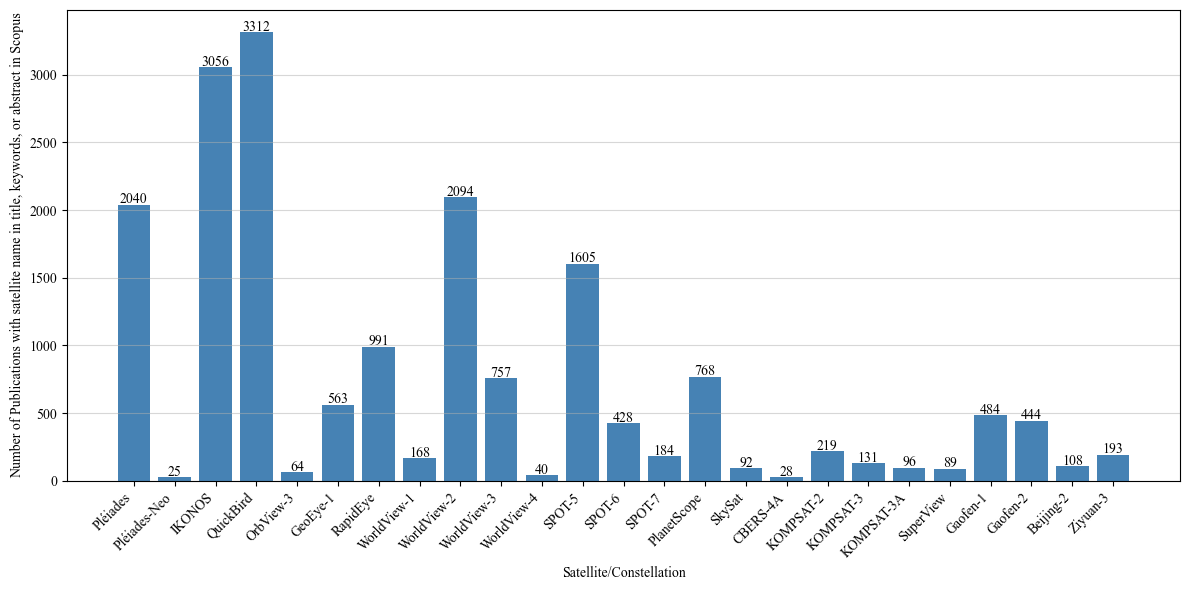

In [18]:
sat_pubs = pd.read_excel(data_path, sheet_name='sat_pubs')

# get launch date from sat_timeline
sat_pubs['Launch Date'] = sat_pubs['Satellite/Constellation'].map(sat_timeline['Launch Date'])

# set Pleaides-Neo launch date to Pleiades-Neo 3 launch date
# print()
sat_pubs.loc[sat_pubs['Satellite/Constellation'] == 'Pléiades-Neo', 'Launch Date'] = sat_timeline.loc[sat_timeline['Satellite/Constellation'] == 'Pléiades-Neo 3']['Launch Date'].values[0]

# set Pleuades launch date to Pleiades 1A launch date
sat_pubs.loc[sat_pubs['Satellite/Constellation'] == 'Pléiades', 'Launch Date'] = sat_timeline.loc[sat_timeline['Satellite/Constellation'] == 'Pléiades-1A']['Launch Date'].values[0]

sat_pubs = sat_pubs.sort_values('Launch Date', ascending=True)

cols = sat_pubs.columns.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x=sat_pubs[cols[0]], height=sat_pubs[cols[1]], color=primary_color)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# ax.set_yscale('log')

ax.set_xlabel(cols[0])
ax.set_ylabel("Number of Publications with satellite name in title, keywords, or abstract in Scopus")
ax.yaxis.grid(True, alpha=0.5)

# use 100, 1000 for y-axis ticks
# ax.set_yticks([100, 1000])
# ax.set_yticklabels([100, 1000])

# add values on top of bars
for i, v in enumerate(sat_pubs[cols[1]]):
    print(i, v)
    ax.text(i, v + 10, str(v), ha='center')
    
fig.tight_layout()

sat_pubs_plot_filename = './sat_pubs.png'
backup(sat_pubs_plot_filename)
plt.savefig(sat_pubs_plot_filename)

plt.show()
plt.close()

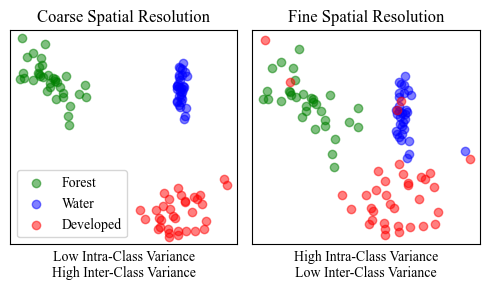

In [19]:
# plots showing inter/intra class variation
from sklearn.datasets import make_classification
fig, ax = plt.subplots(1, 2, figsize=(5, 3))

# create a fake dataset with 2 features, 3 classes, and 100 samples each
class_sep = [4, 2]
for i in range(2):
    n_samples = 100
    n_features = 2
    n_classes = 3
    dataset = make_classification(
        n_features=2, 
        n_informative=2, 
        n_redundant=0, 
        n_clusters_per_class=1, 
        n_classes=3, 
        n_samples=100, 
        random_state=0, 
        class_sep=class_sep[i], 
        flip_y=0.1 * i
    )
    # print(dataset.shape)

    for class_label, color in zip(
        range(n_classes), 
        [['Forest', 'green'], ['Water', 'blue'], ['Developed', 'red']]
    ):
        class_samples = dataset[0][dataset[1] == class_label]
        ax[i].scatter(
            class_samples[:, 0], 
            class_samples[:, 1], 
            color=color[1], 
            label=color[0], 
            alpha=0.5
        )
    
    # remove axis labels
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
    # make the plot square
    # ax[i].set_aspect('equal', adjustable='datalim')

ax[0].set_title('Coarse Spatial Resolution')
ax[0].set_xlabel('Low Intra-Class Variance\nHigh Inter-Class Variance')

ax[1].set_title('Fine Spatial Resolution')
ax[1].set_xlabel('High Intra-Class Variance\nLow Inter-Class Variance')

for i in range(2):
    ax[i].set_aspect('equal', adjustable='datalim')

ax[0].legend()

fig.tight_layout()
plt.savefig('./inter_intra_class_variation.jpg', dpi=300)
